In [1]:
from io import BytesIO
from zipfile import ZipFile, BadZipFile
import requests
from datetime import date, datetime
from pathlib import Path
import pandas_datareader.data as web
import datetime
import pandas as pd
import json
import re
from pprint import pprint
from bs4 import BeautifulSoup
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

In [2]:
plt.style.use('fivethirtyeight')
data_path = Path('../../data/fundamental') # perhaps set to external harddrive to accomodate large amount of data

## Dowload FS & Notes

The following code downloads and extracts all historical filings contained in the [Financial Statement and Notes](https://www.sec.gov/dera/data/financial-statement-and-notes-data-set.html) (FSN) datasets for the given range of quarters:

**Downloads over 40GB of data!**

In [16]:
import pandas as pd
from datetime import date
import requests
from zipfile import ZipFile, BadZipFile
from io import BytesIO
from pathlib import Path
import time
# IMPORTANT: Define your data_path where you want to save the files.
# For example:
# data_path = Path('./sec_data')
# You might want to ensure this directory exists before running the loop.
# data_path.mkdir(exist_ok=True, parents=True) # Uncomment if you want to create it here

# Updated SEC_URL for the main financial statement data sets
SEC_URL = 'https://www.sec.gov/files/dera/data/financial-statement-data-sets/'

today = pd.Timestamp(date.today())
this_year = 2018 # As per your original code
this_quarter = 3 # As per your original code

past_years = range(2017, 2018)  # Adjust the range as needed
filing_periods = [(y, q) for y in past_years for q in range(1, 5)]
filing_periods.extend([(this_year, q) for q in range(1, this_quarter + 1)])

# Define headers to mimic a web browser, otherwise some servers may block the request
headers = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36', # Example of a slightly different User-Agent
    'Accept-Language': 'en-US,en;q=0.9',
    'Accept-Encoding': 'gzip, deflate, br',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7',
    'Connection': 'keep-alive',
    'Referer': 'https://www.sec.gov/data-research/sec-markets-data/financial-statement-data-sets', # Add the referer here
}
print("Attempting to download SEC financial data:")

for i, (yr, qtr) in enumerate(filing_periods, 1):
    print(f"Processing {yr} Q{qtr}", end=' ')
    
    # Updated filing name: removed '_notes'
    filing = f'{yr}q{qtr}.zip'
    
    path = data_path / f'{yr}_{qtr}' / 'source'
    if not path.exists():
        path.mkdir(exist_ok=True, parents=True)

    full_url = SEC_URL + filing
    try:
# Pass the headers with the request
        response = requests.get(full_url, headers=headers, stream=True) # Use stream=True for large files
        response.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)
        
        # Check if the content is likely a zip file before attempting to open
        if response.headers.get('Content-Type') == 'application/zip' or filing.endswith('.zip'):
            # Read content from the stream
            zip_content = BytesIO()
            for chunk in response.iter_content(chunk_size=8192): # Read in chunks
                zip_content.write(chunk)
            zip_content.seek(0) # Rewind to the beginning

            with ZipFile(zip_content) as zip_file:
                for file in zip_file.namelist():
                    local_file = path / file
                    if local_file.exists():
                        print(f" (Skipping existing file: {file})", end='')
                        continue
                    print(f" (Extracting: {file})", end='')
                    with local_file.open('wb') as output:
                        output.write(zip_file.open(file).read())
            print(" - Success")
        else:
            print(f" - WARNING: Received non-zip content for {full_url}. Content-Type: {response.headers.get('Content-Type')}")

    except requests.exceptions.RequestException as e:
        print(f" - ERROR: Could not download {full_url} - {e}")
    except BadZipFile:
        print(f" - ERROR: Received a corrupted or invalid zip file from {full_url}")
    except Exception as e:
        print(f" - An unexpected error occurred: {e}")
    # Add a delay between requests (e.g., 2 seconds) for rate limiting
    # time.sleep(2)

Attempting to download SEC financial data:
Processing 2017 Q1  - ERROR: Could not download https://www.sec.gov/files/dera/data/financial-statement-data-sets/2017q1.zip - 403 Client Error: Forbidden for url: https://www.sec.gov/files/dera/data/financial-statement-data-sets/2017q1.zip
Processing 2017 Q2  - ERROR: Could not download https://www.sec.gov/files/dera/data/financial-statement-data-sets/2017q2.zip - 403 Client Error: Forbidden for url: https://www.sec.gov/files/dera/data/financial-statement-data-sets/2017q2.zip
Processing 2017 Q3  - ERROR: Could not download https://www.sec.gov/files/dera/data/financial-statement-data-sets/2017q3.zip - 403 Client Error: Forbidden for url: https://www.sec.gov/files/dera/data/financial-statement-data-sets/2017q3.zip
Processing 2017 Q4  - ERROR: Could not download https://www.sec.gov/files/dera/data/financial-statement-data-sets/2017q4.zip - 403 Client Error: Forbidden for url: https://www.sec.gov/files/dera/data/financial-statement-data-sets/2017

## Save to parquet

The data is fairly large and to enable faster access than the original text files permit, it is better to convert the text files to binary, columnar parquet format (see Section 'Efficient data storage with pandas' in chapter 2 for a performance comparison of various data-storage options compatible with pandas DataFrames):

In [18]:
for f in data_path.glob('**/*.txt'):
    file_name = f.stem  + '.parquet'
    path = Path(f.parents[1]) / 'parquet'
    if (path / file_name).exists():
        continue
    if not path.exists():
        path.mkdir(exist_ok=True)
    try:
        df = pd.read_csv(f, sep='\t', encoding='latin1', low_memory=False)
    except:
        print(f)
    df.to_parquet(path / file_name)

## Metadata json

In [19]:
# no json anymore, only htm file
# file = data_path / '2018_3' / 'source' / '2018q3_notes-metadata.json'
# with file.open() as f:
#     data = json.load(f)

# pprint(data)

## Data Organization

For each quarter, the FSN data is organized into eight file sets that contain information about submissions, numbers, taxonomy tags, presentation, and more. Each dataset consists of rows and fields and is provided as a tab-delimited text file:

| File | Dataset      | Description                                                 |
|------|--------------|-------------------------------------------------------------|
| SUB  | Submission   | Identifies each XBRL submission by company, form, date, etc |
| TAG  | Tag          | Defines and explains each taxonomy tag                      |
| DIM  | Dimension    | Adds detail to numeric and plain text data                  |
| NUM  | Numeric      | One row for each distinct data point in filing              |
| TXT  | Plain Text   | Contains all non-numeric XBRL fields                        |
| REN  | Rendering    | Information for rendering on SEC website                    |
| PRE  | Presentation | Detail on tag and number presentation in primary statements |
| CAL  | Calculation  | Shows arithmetic relationships among tags                   |

## Submission Data

The latest submission file contains around 6,500 entries.

In [20]:
sub = pd.read_parquet(data_path / '2018_3' / 'parquet' / 'sub.parquet')
sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 36 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   adsh        6493 non-null   object 
 1   cik         6493 non-null   int64  
 2   name        6493 non-null   object 
 3   sic         6493 non-null   int64  
 4   countryba   6482 non-null   object 
 5   stprba      5900 non-null   object 
 6   cityba      6482 non-null   object 
 7   zipba       6478 non-null   object 
 8   bas1        6482 non-null   object 
 9   bas2        2804 non-null   object 
 10  baph        6482 non-null   object 
 11  countryma   6448 non-null   object 
 12  stprma      5906 non-null   object 
 13  cityma      6448 non-null   object 
 14  zipma       6447 non-null   object 
 15  mas1        6448 non-null   object 
 16  mas2        2761 non-null   object 
 17  countryinc  5936 non-null   object 
 18  stprinc     5632 non-null   object 
 19  ein         6492 non-null  

In [29]:
sub.head()

,adsh,cik,name,sic,countryba,stprba,cityba,zipba,bas1,bas2,...,period,fy,fp,filed,accepted,prevrpt,detail,instance,nciks,aciks
0,0000002178-18-000057,2178,"ADAMS RESOURCES & ENERGY, INC.",5172,US,TX,HOUSTON,77027,17 S. BRIAR HOLLOW LN.,None,...,20180630,2018.0,Q2,20180808,2018-08-08 16:47:00.0,0,1,ae-20180630_htm.xml,1,None
1,0000002488-18-000128,2488,ADVANCED MICRO DEVICES INC,3674,US,CA,SANTA CLARA,95054,2485 AUGUSTINE DRIVE,None,...,20180630,2018.0,Q2,20180802,2018-08-02 16:29:00.0,0,1,amd-20180630.xml,1,None
2,0000002969-18-000034,2969,AIR PRODUCTS & CHEMICALS INC /DE/,2810,US,PA,ALLENTOWN,18195-1501,7201 HAMILTON BLVD,None,...,20180630,2018.0,Q3,20180726,2018-07-26 15:25:00.0,0,1,apd-10qx30jun2018_htm.xml,1,None
3,0000003499-18-000018,3499,ALEXANDERS INC,6798,US,NJ,PARAMUS,07652,210 ROUTE 4 EAST,None,...,20180630,2018.0,Q2,20180730,2018-07-30 08:24:00.0,0,1,alx-20180630.xml,1,None
4,0000003545-18-000066,3545,ALICO INC,100,US,FL,"FT. MYERS,",33913,10070 DANIELS INTERSTATE COURT STE. 100,None,...,20180630,2018.0,Q3,20180806,2018-08-06 17:03:00.0,0,1,alco-20180630.xml,1,None


### Get AAPL submission

The submission dataset contains the unique identifiers required to retrieve the filings: the Central Index Key (CIK) and the Accession Number (adsh). The following shows some of the information about Apple's 2018Q1 10-Q filing:

In [21]:
name = 'APPLE INC'
apple = sub[sub.name == name].T.dropna().squeeze()
key_cols = ['name', 'adsh', 'cik', 'name', 'sic', 'countryba', 'stprba',
            'cityba', 'zipba', 'bas1', 'form', 'period', 'fy', 'fp', 'filed']
apple.loc[key_cols]

name                    APPLE INC
adsh         0000320193-18-000100
cik                        320193
name                    APPLE INC
sic                          3571
countryba                      US
stprba                         CA
cityba                  CUPERTINO
zipba                       95014
bas1           ONE APPLE PARK WAY
form                         10-Q
period                   20180630
fy                         2018.0
fp                             Q3
filed                    20180801
Name: 386, dtype: object

## Build AAPL fundamentals dataset

Using the central index key, we can identify all historical quarterly filings available for Apple, and combine this information to obtain 26 Forms 10-Q and nine annual Forms 10-K.

### Get filings

In [22]:
aapl_subs = pd.DataFrame()
for sub in data_path.glob('**/sub.parquet'):
    sub = pd.read_parquet(sub)
    aapl_sub = sub[(sub.cik.astype(int) == apple.cik) & (sub.form.isin(['10-Q', '10-K']))]
    aapl_subs = pd.concat([aapl_subs, aapl_sub])

We find 15 quarterly 10-Q and 4 annual 10-K reports:

In [23]:
aapl_subs.form.value_counts()

form
10-Q    1
Name: count, dtype: int64

### Get numerical filing data

With the Accession Number for each filing, we can now rely on the taxonomies to select the appropriate XBRL tags (listed in the TAG file) from the NUM and TXT files to obtain the numerical or textual/footnote data points of interest.

First, let's extract all numerical data available from the 19 Apple filings:

In [30]:
aapl_nums = pd.DataFrame()
for num in data_path.glob('**/num.parquet'):
    num = pd.read_parquet(num).drop('dimh', axis=1, errors='ignore')  # Drop 'dimh' if it exists
    # Filter for Apple Inc. using the 'adsh' column from aapl_subs
    aapl_num = num[num.adsh.isin(aapl_subs.adsh)]
    print(len(aapl_num))
    aapl_nums = pd.concat([aapl_nums, aapl_num])
aapl_nums.ddate = pd.to_datetime(aapl_nums.ddate, format='%Y%m%d')   
aapl_nums.to_parquet(data_path / 'aapl_nums.parquet')

415


In total, the nine years of filing history provide us with over 18,000 numerical values for AAPL.

In [31]:
aapl_nums.info()

<class 'pandas.core.frame.DataFrame'>
Index: 415 entries, 6092 to 2627120
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   adsh      415 non-null    object        
 1   tag       415 non-null    object        
 2   version   415 non-null    object        
 3   ddate     415 non-null    datetime64[ns]
 4   qtrs      415 non-null    int64         
 5   uom       415 non-null    object        
 6   segments  167 non-null    object        
 7   coreg     0 non-null      object        
 8   value     413 non-null    float64       
 9   footnote  0 non-null      object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 35.7+ KB


In [38]:
aapl_nums.head()

,adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote
6092,0000320193-18-000100,AvailableForSaleSecuritiesCurrent,us-gaap/2017,2017-09-30,0,USD,FairValueByFairValueHierarchyLevel=FairValueIn...,None,1.494000e+09,None
18870,0000320193-18-000100,AvailableForSaleSecuritiesNoncurrent,us-gaap/2017,2017-09-30,0,USD,FairValueByFairValueHierarchyLevel=FairValueIn...,None,1.256880e+11,None
23906,0000320193-18-000100,NonoperatingIncomeExpense,us-gaap/2017,2018-06-30,3,USD,DerivativeInstrumentRisk=ForeignExchangeContra...,None,-4.410000e+08,None
25779,0000320193-18-000100,AvailableForSaleSecuritiesCurrent,us-gaap/2017,2018-06-30,0,USD,FairValueByFairValueHierarchyLevel=FairValueIn...,None,1.124000e+09,None
35465,0000320193-18-000100,DeferredIncomeTaxExpenseBenefit,us-gaap/2017,2017-12-31,1,USD,TaxCutsandJobsAct=TaxCutsandJobsActDeemedRepat...,None,-3.610000e+10,None


## Create P/E Ratio from EPS and stock price data

We can select a useful field, such as Earnings per Diluted Share (EPS), that we can combine with market data to calculate the popular Price/Earnings (P/E) valuation ratio.

In [32]:
stock_split = 7
split_date = pd.to_datetime('20140604')
split_date

Timestamp('2014-06-04 00:00:00')

We do need to take into account, however, that Apple split its stock 7:1 on June 4, 2014, and Adjusted Earnings per Share before the split to make earnings comparable, as illustrated in the following code block:

In [46]:
# Filter by tag; keep only values measuring 1 quarter
eps = aapl_nums[(aapl_nums.tag == 'EarningsPerShareDiluted')
                & (aapl_nums.qtrs == 1)].drop('tag', axis=1)
print(eps.shape)
eps.head()

(2, 9)


,adsh,version,ddate,qtrs,uom,segments,coreg,value,footnote
560842,0000320193-18-000100,us-gaap/2017,2018-06-30,1,USD,None,None,2.34,None
993011,0000320193-18-000100,us-gaap/2017,2017-06-30,1,USD,None,None,1.67,None


In [47]:

# Keep only most recent data point from each filing
eps = eps.groupby('adsh').apply(lambda x: x.nlargest(n=1, columns=['ddate']))
print(eps.shape)
# Adjust earnings prior to stock split downward
eps.loc[eps.ddate < split_date,'value'] = eps.loc[eps.ddate < split_date, 'value'].div(7)
# eps = eps[['ddate', 'value']].set_index('ddate').squeeze().sort_index()
# Corrected line:
# 1. Set 'ddate' as the index.
# 2. Select the 'value' column to ensure it's a Series.
# 3. Then sort the index.
eps = eps.set_index('ddate')['value'].sort_index()
print(eps.shape)
eps.head()


(1, 9)
(1,)


/var/folders/_1/hlx9skzx2wd47fbwgn286hkm0000gn/T/ipykernel_8084/1549375854.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eps = eps.groupby('adsh').apply(lambda x: x.nlargest(n=1, columns=['ddate']))


ddate
2018-06-30    2.34
Name: value, dtype: float64

In [ ]:
eps = eps.rolling(4,min_periods=4).sum().dropna()

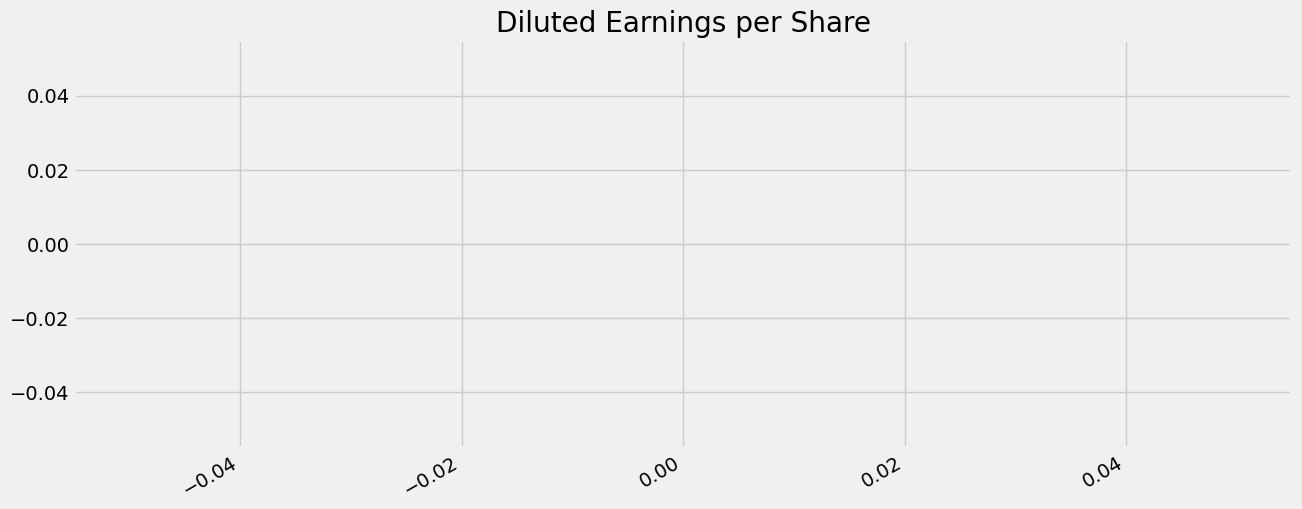

In [36]:
eps.plot(lw=2, figsize=(14, 6), title='Diluted Earnings per Share')
plt.xlabel('')
plt.savefig('diluted eps', dpi=300);

In [52]:
import yfinance as yf
import pandas as pd

# Ensure 'eps' DataFrame is defined and has a datetime index as in previous turns.
# For demonstration purposes, if eps is not defined, here's a placeholder:
# from datetime import date
# data = {'value': [10.0, 11.0, 12.0, 13.0, 14.0, 15.0]}
# dates = pd.to_datetime(['2014-01-01', '2014-04-01', '2014-07-01', '2014-10-01', '2015-01-01', '2015-04-01'])
# eps = pd.Series(data['value'], index=dates)


symbol = 'AAPL.US'

# YFinance uses standard ticker symbols, so remove the '.US' suffix.
ticker_symbol = symbol.replace('.US', '')

# Define the start and end dates from the 'eps' DataFrame's index.
start_date = datetime.datetime(2014, 1, 1)  # You can set this to a specific date or use eps.index.min() if eps is defined
end_date = eps.index.max()

print(f"Attempting to fetch {ticker_symbol} stock data directly from Yahoo Finance from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}...")

# Create a Ticker object for the symbol
aapl_ticker = yf.Ticker(ticker_symbol)

# Download historical data for the specified date range
# yfinance.history() by default returns daily data.
# The index will be the date, and columns will include Open, High, Low, Close, Volume, Dividends, Stock Splits.
aapl_stock = aapl_ticker.history(start=start_date, end=end_date)

# Apply resampling and filtering as in your original code.
# .resample('D').last() is often redundant if yfinance already returns daily data,
# but keeping it for consistency if you had specific resampling needs.
# .loc slicing uses string representations of years for broad filtering.
aapl_stock = aapl_stock.resample('D').last().loc[str(start_date.year):str(end_date.year)]


print("\nSuccessfully fetched AAPL stock data:")
aapl_stock.info()
print("\nFirst 5 rows:")
print(aapl_stock.head())
print("\nLast 5 rows:")
print(aapl_stock.tail())

Attempting to fetch AAPL stock data directly from Yahoo Finance from 2014-01-01 to 2018-06-30...

Successfully fetched AAPL stock data:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1640 entries, 2014-01-02 00:00:00-05:00 to 2018-06-29 00:00:00-04:00
Freq: D
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          1132 non-null   float64
 1   High          1132 non-null   float64
 2   Low           1132 non-null   float64
 3   Close         1132 non-null   float64
 4   Volume        1132 non-null   float64
 5   Dividends     1132 non-null   float64
 6   Stock Splits  1132 non-null   float64
dtypes: float64(7)
memory usage: 102.5 KB

First 5 rows:
                                Open       High        Low      Close  \
Date                                                                    
2014-01-02 00:00:00-05:00  17.272089  17.314050  17.158326  17.192827   
2014-01-03 00:00:00-05:00  17.184440  1

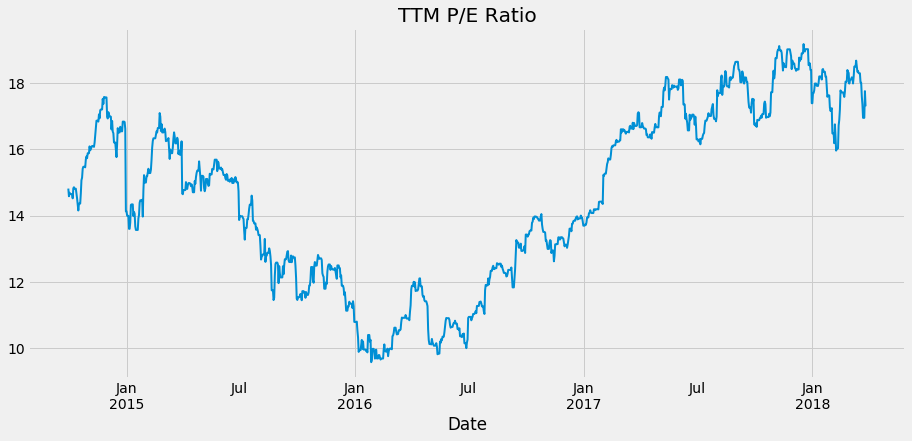

In [19]:
pe = aapl_stock.AdjClose.to_frame('price').join(eps.to_frame('eps'))
pe = pe.fillna(method='ffill').dropna()
pe['P/E Ratio'] = pe.price.div(pe.eps)
pe['P/E Ratio'].plot(lw=2, figsize=(14, 6), title='TTM P/E Ratio');

In [20]:
pe.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1275 entries, 2014-09-30 to 2018-03-27
Freq: D
Data columns (total 3 columns):
price        1275 non-null float64
eps          1275 non-null float64
P/E Ratio    1275 non-null float64
dtypes: float64(3)
memory usage: 39.8 KB


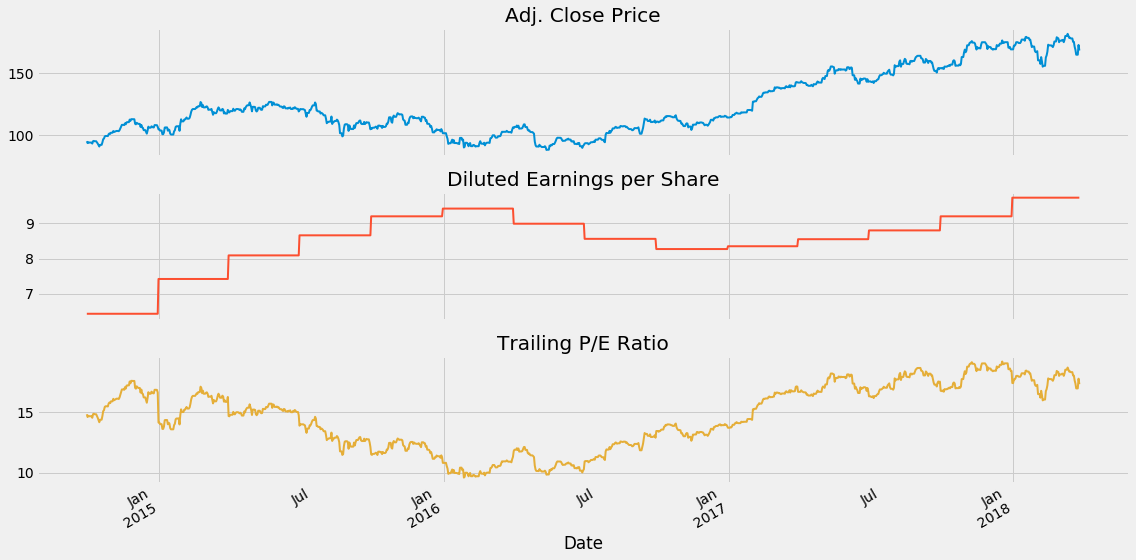

In [21]:
axes = pe.plot(subplots=True, figsize=(16,8), legend=False, lw=2)
axes[0].set_title('Adj. Close Price')
axes[1].set_title('Diluted Earnings per Share')
axes[2].set_title('Trailing P/E Ratio')
plt.tight_layout();

## Explore Additional Fields

The field `tag` references values defined in the taxonomy:

In [22]:
aapl_nums.tag.value_counts()

DebtInstrumentInterestRateEffectivePercentage                                                                        573
CashAndCashEquivalentsAtCarryingValue                                                                                570
SalesRevenueNet                                                                                                      544
AvailableForSaleSecuritiesNoncurrent                                                                                 532
AvailableForSaleSecurities                                                                                           532
AvailableForSaleSecuritiesCurrent                                                                                    532
AvailableForSaleSecuritiesAmortizedCost                                                                              532
AvailableForSaleSecuritiesAccumulatedGrossUnrealizedLossBeforeTax                                                    476
AvailableForSaleSecuritiesAccumu

We can select values of interest and track their value or use them as inputs to compute fundamental metrics like the Dividend/Share ratio.

### Dividends per Share

In [53]:
fields = ['EarningsPerShareDiluted',
          'PaymentsOfDividendsCommonStock',
          'WeightedAverageNumberOfDilutedSharesOutstanding',
          'OperatingIncomeLoss',
          'NetIncomeLoss',
          'GrossProfit']

IndexError: index 0 is out of bounds for axis 0 with size 0

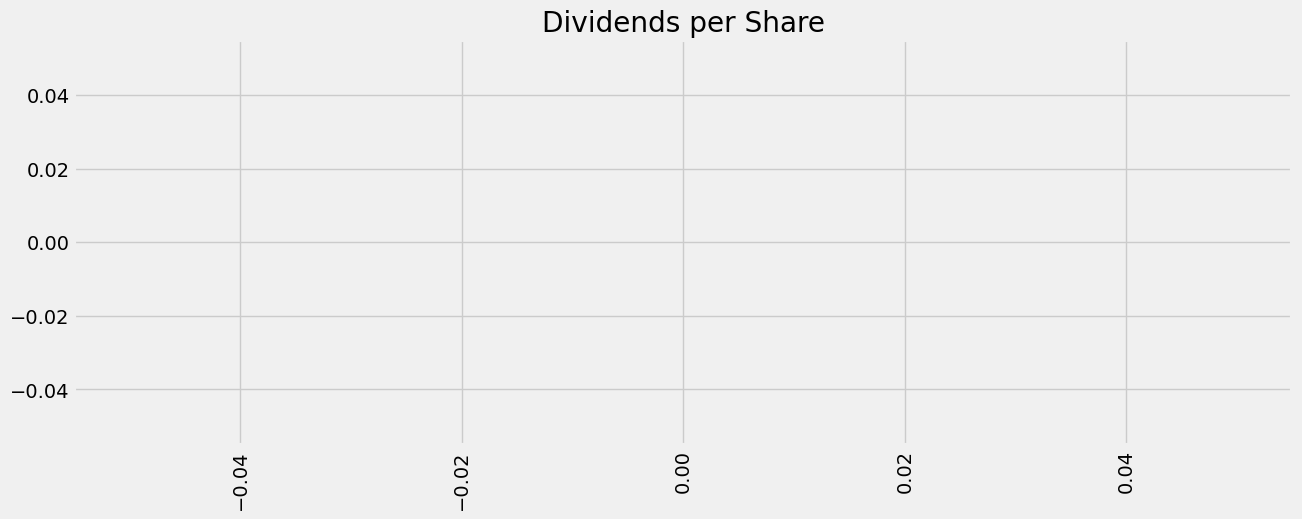

In [54]:
dividends = (aapl_nums
             .loc[aapl_nums.tag == 'PaymentsOfDividendsCommonStock', ['ddate', 'value']]
             .groupby('ddate')
             .mean())
shares = (aapl_nums
          .loc[aapl_nums.tag == 'WeightedAverageNumberOfDilutedSharesOutstanding', ['ddate', 'value']]
          .drop_duplicates()
          .groupby('ddate')
          .mean())
df = dividends.div(shares).dropna()
ax = df.plot.bar(figsize=(14, 5), title='Dividends per Share', legend=False)
ax.xaxis.set_major_formatter(mticker.FixedFormatter(df.index.strftime('%Y-%m')))

## Bonus: Textual Information

In [56]:
txt = pd.read_parquet(data_path / '2018_3' / 'parquet' /  'tag.parquet')

In [57]:
txt.head()

,tag,version,custom,abstract,datatype,iord,crdr,tlabel,doc
0,InterestIncomeSecuritiesNonAgencyMortgageBacked,0001516973-18-000031,1,0,monetary,D,C,Interest Income Securities Non Agency Mortgage...,Interest Income Securities Non Agency Mortgage...
1,RepaymentsofLongtermLeaseFinancingObligations,0001596532-18-000174,1,0,monetary,D,C,Repayments of Long-term Lease Financing Obliga...,Repayments of Long-term Lease Financing Obliga...
2,StockBasedCompensationDueToCommonStockPurchase...,0001477932-18-003532,1,0,monetary,D,C,Stock based compensation due to common stock p...,Stock based compensation due to common stock p...
3,IncreaseDecreaseInPrepaidExpensesAndOtherCurre...,0001558370-18-006644,1,0,monetary,D,C,Increase Decrease In Prepaid Expenses And Othe...,The increase (decrease) during the reporting p...
4,FairValueOfDerivativesAndSettlementOfLiabiliti...,0001267395-18-000093,1,0,monetary,D,C,Fair Value Of Derivatives And Settlement Of Li...,Fair value of derivatives and settlement of li...
